# Case 1: 2D Facial Pose (MATB) — reproduction

This notebook walks through the full Case-1 pipeline on the MATB facial-pose data
and reproduces the paper's figure (pupil velocity, pupil %REC, cross gaze–head
%REC, and pupil %DET across Low/Moderate/High cognitive load).

It follows the workflow a user would run:

1. **Load & preprocess** a trial (confidence mask → interpolation → filter).
2. **Choose the embedding parameters** `(τ, m)` from AMI/FNN evidence — the
   framework proposes, *you* commit.
3. **Run the reproduction** across participants.
4. **Reproduce the figure.**

All analysis logic lives in the library; this notebook only calls it.

## Configuration

Set the data location and the **run toggle**. `RUN_FULL = False` analyzes a fast
subset (good for iterating); `RUN_FULL = True` runs all 72 participants (216
trials, ~15–25 min) to reproduce the published figure.

In [1]:
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# >>> point this at your MATB raw OpenPose exports <<<
DATA_DIR = "/Volumes/X9_Pro/MRes_MATB/Pose/data/raw_data/experimental_pose"

# --- run toggle ---
RUN_FULL   = True   # False = quick subset; True = all participants (the paper figure)
N_SUBSET   = 12      # trials analyzed when RUN_FULL is False
N_EMBED     = 6      # trials pooled for the AMI/FNN evidence

files = sorted(glob.glob(f"{DATA_DIR}/*.csv"))
run_files = files if RUN_FULL else files[:N_SUBSET]
print(f"{len(files)} trials available; analyzing {len(run_files)} "
      f"({'FULL' if RUN_FULL else 'subset'}).")

216 trials available; analyzing 216 (FULL).


## 1. Load and preprocess a trial

`load_matb_file` reads the raw OpenPose export (`x{n}, y{n}, prob{n}`, 1-based) and
returns a `PoseSequence`. `preprocess` applies the Case-1 settings: confidence
mask at 0.30, run-limited interpolation (≤ 60 frames), and a 4th-order 10 Hz
zero-phase Butterworth filter. The coverage plot is the preprocessing checkpoint.

{'source_file': '/Volumes/X9_Pro/MRes_MATB/Pose/data/raw_data/experimental_pose/402_H.csv', 'n_frames': 28835, 'n_keypoints': 70, 'dims': 2, 'frame_rate': 60.0, 'duration_s': 480.583, 'has_confidence': True, 'missing_fraction': 0.0, 'stages_applied': ['confidence_mask', 'provisional_interpolation', 'butterworth_filter'], 'meta': {'participant': '402', 'condition': 'H'}}


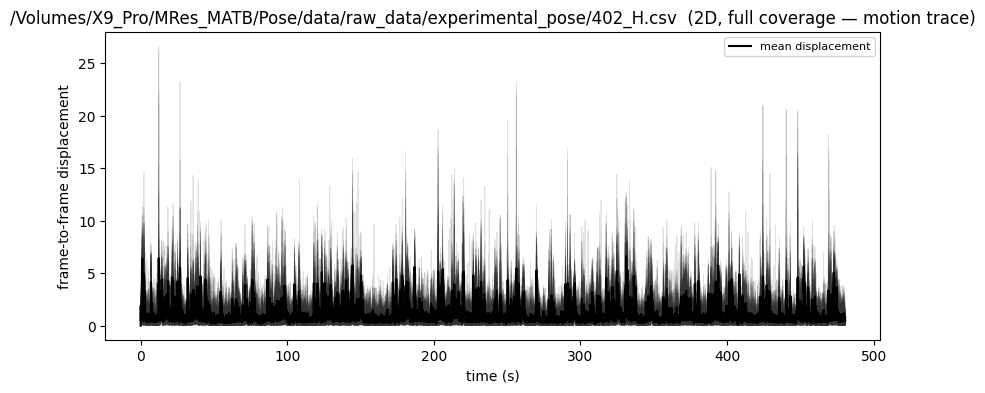

In [2]:
from pose_dynamics.case_studies.matb import load_matb_file, preprocess

seq = preprocess(load_matb_file(run_files[0]))
print(seq.summary())
seq.plot_coverage();

## 2. Choosing the embedding parameters (human-in-the-loop)

AMI and FNN are computed across many signals (here, per-keypoint speed pooled over
a handful of trials). The framework **presents the evidence and proposes** `(τ, m)`
using relative-shape/plateau logic for τ and the diminishing-returns knee for m —
but it does **not** decide. You read the plots and commit.

Evidence from 60 of 420 signals.

Delay (tau) — relative-shape / plateau heuristic (proposal, confirm from the plot):
  - first prominent local minimum (smoothed) at lag None.
  - plateau onset (diminishing returns) at lag 17.
  - relative 1/e crossing at lag 3.
  - per-signal median suggestion: 16.0.
  => proposed tau = 17.

Dimension (m) — FNN diminishing-returns knee at tau=17:
  - knee (elbow of the FNN curve): 4.
  - first dimension with FNN <= 10% (noise floor): 7.
  - per-signal median: 4.0.
  => proposed m = 4.

NOTE: these are proposals, not decisions. Inspect the curves and their spread, then commit a single (tau, m) with evidence.commit(tau, m).


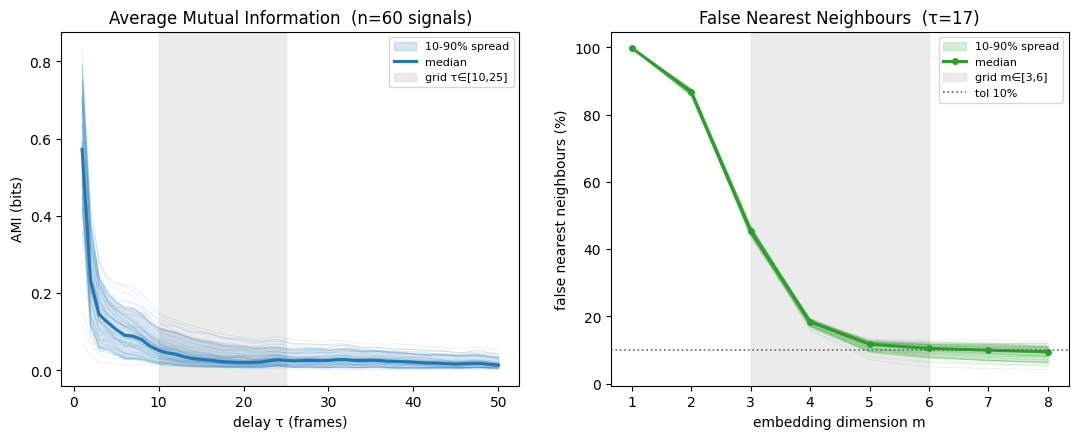

In [3]:
from pose_dynamics.embedding import (select_embedding, pool_signals, magnitude_channels,
                                     plot_embedding_evidence, plot_embedding_variability)

sample = [preprocess(load_matb_file(f)) for f in files[:N_EMBED]]
signals = pool_signals(sample, magnitude_channels)

evidence = select_embedding(signals, tau_grid=(10, 25), m_grid=(3, 6),
                            ami_max_lag=50, fnn_max_dim=8, subset=60, seed=0)
plot_embedding_evidence(evidence)
print(evidence.justification)

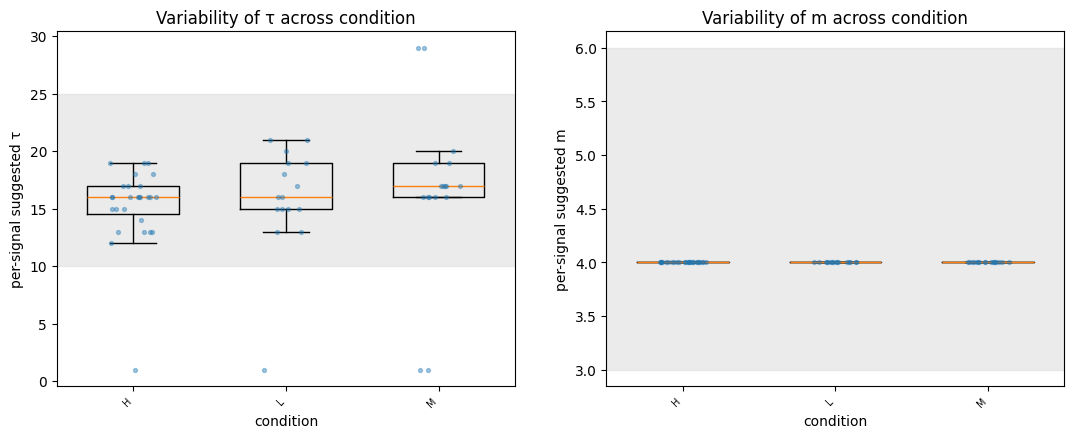

In [4]:
# optional: does (tau, m) drift systematically across conditions?
plot_embedding_variability(evidence, group_by="condition");

### Commit the choice

The evidence proposes τ≈17–20 (AMI plateau) and m=4 (FNN knee). Consistent with
the paper, we commit **τ = 20, m = 4**, applied fixed across the whole study.
`evidence.commit` records the decision (and warns if it is outside the presented
grid or below the proposed dimension). These are exactly the values in the Case-1
config (`pose_dynamics.case_studies.matb.config`: `TAU = 20`, `M = 4`).

In [5]:
params = evidence.commit(tau=20, m=4, notes="Case 1: AMI plateau ~ quarter-cycle; FNN knee at 4")
params.to_dict()

{'tau': 20,
 'm': 4,
 'multivariate': False,
 'chosen_by': 'human_confirmed',
 'proposed_tau': 17,
 'proposed_m': 4,
 'n_signals': 60,
 'notes': 'Case 1: AMI plateau ~ quarter-cycle; FNN knee at 4'}

## 3. Run the reproduction

`run_reproduction` streams every selected trial through the full Case-1 pipeline:

- normalize to screen → **anisotropic Procrustes** emitting *both* streams
  (aligned geometry **and** head-motion parameters),
- ten analysis signals on the aligned coordinates: pupil displacement (x, y,
  magnitude), blink aperture, mouth aperture, and the five head-motion
  parameters (translation magnitude, rotation, scale x/y, combined magnitude),
- 60 s windows (50% overlap), then per window and per signal: the linear
  kinematic summaries (mean/SD/min/max/RMS × position/velocity/acceleration)
  and the **full auto-RQA metric set**; plus **full cross-RQA** between head
  motion and each of the three pupil components.

Controlled by the `RUN_FULL` toggle above.

In [6]:
from pose_dynamics.case_studies.matb import run_reproduction

df = run_reproduction(run_files, template_sample=24, progress=True)
print(f"{len(df)} window-rows")
df.head()

[template 1/24] 402_H.csv
[template 2/24] 402_L.csv
[template 3/24] 402_M.csv
[template 4/24] 404_H.csv
[template 5/24] 404_L.csv
[template 6/24] 404_M.csv
[template 7/24] 407_H.csv
[template 8/24] 407_L.csv
[template 9/24] 407_M.csv
[template 10/24] 408_H.csv
[template 11/24] 408_L.csv
[template 12/24] 408_M.csv
[template 13/24] 409_H.csv
[template 14/24] 409_L.csv
[template 15/24] 409_M.csv
[template 16/24] 410_H.csv
[template 17/24] 410_L.csv
[template 18/24] 410_M.csv
[template 19/24] 411_H.csv
[template 20/24] 411_L.csv
[template 21/24] 411_M.csv
[template 22/24] 412_H.csv
[template 23/24] 412_L.csv
[template 24/24] 412_M.csv
[analyze 1/216] 402_H
[analyze 2/216] 402_L
[analyze 3/216] 402_M
[analyze 4/216] 404_H
[analyze 5/216] 404_L
[analyze 6/216] 404_M
[analyze 7/216] 407_H
[analyze 8/216] 407_L
[analyze 9/216] 407_M
[analyze 10/216] 408_H
[analyze 11/216] 408_L
[analyze 12/216] 408_M
[analyze 13/216] 409_H
[analyze 14/216] 409_L
[analyze 15/216] 409_M
[analyze 16/216] 410_H
[a

/Users/cartersale/Research/projects/pose_dynamics/src/pose_dynamics/features/primitives.py:438: RuntimeWarning: Mean of empty slice
  c = np.nanmean(coords[:, cen, :], axis=1)


[analyze 152/216] 456_L
[analyze 153/216] 456_M
[analyze 154/216] 457_H
[analyze 155/216] 457_L
[analyze 156/216] 457_M
[analyze 157/216] 458_H
[analyze 158/216] 458_L
[analyze 159/216] 458_M
[analyze 160/216] 459_H
[analyze 161/216] 459_L
[analyze 162/216] 459_M
[analyze 163/216] 460_H
[analyze 164/216] 460_L
[analyze 165/216] 460_M
[analyze 166/216] 461_H
[analyze 167/216] 461_L
[analyze 168/216] 461_M
[analyze 169/216] 462_H
[analyze 170/216] 462_L
[analyze 171/216] 462_M
[analyze 172/216] 463_H
[analyze 173/216] 463_L
[analyze 174/216] 463_M
[analyze 175/216] 464_H
[analyze 176/216] 464_L
[analyze 177/216] 464_M
[analyze 178/216] 465_H
[analyze 179/216] 465_L
[analyze 180/216] 465_M
[analyze 181/216] 466_H
[analyze 182/216] 466_L
[analyze 183/216] 466_M
[analyze 184/216] 467_H
[analyze 185/216] 467_L
[analyze 186/216] 467_M
[analyze 187/216] 468_H
[analyze 188/216] 468_L
[analyze 189/216] 468_M
[analyze 190/216] 469_H
[analyze 191/216] 469_L
[analyze 192/216] 469_M
[analyze 193/216

,participant,condition,window_index,flagged,pupil_metric_vel_rms,pupil_metric_perc_recur,pupil_metric_perc_determ,crqa_head_pupil_mag_perc_recur
0,402,H,0,False,0.015344,0.501303,17.136120,3.299858
1,402,H,1,False,0.012558,0.559908,19.290788,1.745922
2,402,H,2,False,0.012935,0.374715,10.759197,1.810048
3,402,H,3,False,0.015249,0.308874,7.953664,2.508499
4,402,H,4,False,0.013927,0.468989,8.763325,3.355310


In [7]:
# save the tidy results (one row per trial x window)
df.to_csv("matb_case1_results.csv", index=False)

## 4. Reproduce the figure

Group-averaged metrics (mean ± SEM across windows) for each load level — the same
four panels as the paper's Case-1 figure.

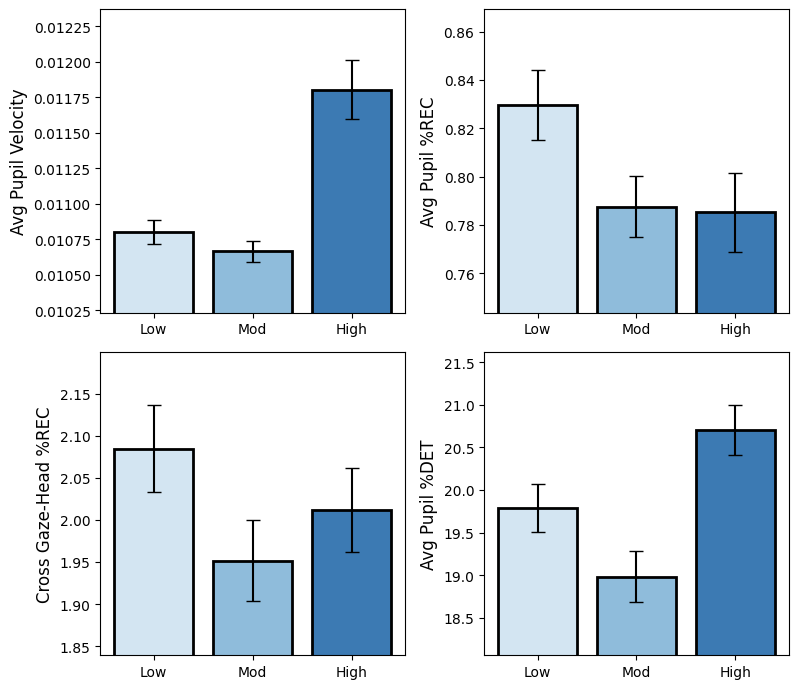

In [8]:
from pose_dynamics.case_studies.matb import plot_case1_figure
plot_case1_figure(df);

## 5. Inferential statistics (dataset-specific)

The package emits only the tidy results table; the models here are specific to the
MATB dataset and live in the notebook. Linear mixed-effects models with a fixed
effect of cognitive-load condition (Low as reference) and a random intercept for
participant give the condition effects (Moderate, High vs. Low) per metric.

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd
import warnings; warnings.simplefilter("ignore")
from pose_dynamics.case_studies.matb import config as C

# Headline metrics per signal: linear velocity RMS + the core RQA set.
RQA_KEYS = ["perc_recur", "perc_determ", "laminarity",
            "mean_line_length", "maxl_found", "entropy", "trapping_time"]
metrics = [f"{f}_vel_rms" for f in C.AUTO_FEATURES]
metrics += [f"{f}_{k}" for f in C.AUTO_FEATURES for k in RQA_KEYS]
metrics += [f"crqa_{g}_{k}" for g, _ in C.CROSS_PAIRS for k in RQA_KEYS]

# Both reference levels: L gives M-L and H-L; M gives the H-M contrast the
# paper reports alongside them.
coef_rows = []
for metric in metrics:
    if metric not in df.columns or df[metric].isna().all():
        continue
    for ref, wanted in [("L", ["M", "H"]), ("M", ["H"])]:
        m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('{ref}'))",
                        df, groups=df["participant"]).fit()
        for lvl in wanted:
            term = f"C(condition, Treatment('{ref}'))[T.{lvl}]"
            coef_rows.append({"metric": metric, "contrast": f"{lvl}-{ref}",
                              "beta": m.params[term], "SE": m.bse[term],
                              "p": m.pvalues[term],
                              "d": m.params[term] / df[metric].std()})

coefs = pd.DataFrame(coef_rows)
coefs.to_csv("matb_case1_condition_effects.csv", index=False)
print(f"{len(coefs)} contrasts across {coefs.metric.nunique()} metrics")
coefs.round(4)

## 6. Parameter sensitivity

The committed `(τ, m) = (20, 4)` and the fixed radii are single points in a
plausible parameter space. As in Case 3, we refit the condition effects across a
grid to check that the *relative* differences between load levels survive — not
that the absolute recurrence values are invariant, which they are not and should
not be expected to be.

Both sweeps run on a 24-participant subset (72 trials) to keep the cost bounded;
`SWEEP_PARTS` controls that.

In [ ]:
from pose_dynamics.case_studies.matb import run_embedding_sweep, run_radius_sweep

SWEEP_PARTS = 24
parts = sorted({Path(f).stem.split("_")[0] for f in files})[:SWEEP_PARTS]
sweep_files = [f for f in files if Path(f).stem.split("_")[0] in parts]
print(f"sweep subset: {len(parts)} participants, {len(sweep_files)} trials")

rad = run_radius_sweep(sweep_files, radii=[0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
                       template_sample=24, progress=False)
rad.to_csv("matb_case1_radius_sweep.csv", index=False)

emb = run_embedding_sweep(sweep_files, taus=[10, 15, 20, 25, 30], ms=[3, 4, 5, 6],
                          template_sample=24, progress=False)
emb.to_csv("matb_case1_embedding_sweep.csv", index=False)
print(rad.shape, emb.shape)

In [ ]:
# Refit the M-L and H-M contrasts at every parameter setting and check that the
# sign and significance of each effect survive.
def sweep_effects(sweep, group_cols, metric="perc_recur"):
    out = []
    for keys, g in sweep.groupby(list(group_cols) + ["analysis"], observed=True):
        for ref, lvl in [("L", "M"), ("M", "H")]:
            sub = g[g.condition.isin([ref, lvl])]
            if sub[metric].isna().all():
                continue
            fit = smf.mixedlm(f"{metric} ~ C(condition, Treatment('{ref}'))",
                              sub, groups=sub["participant"]).fit()
            term = f"C(condition, Treatment('{ref}'))[T.{lvl}]"
            out.append(dict(zip(list(group_cols) + ["analysis"], keys)) |
                       {"contrast": f"{lvl}-{ref}", "beta": fit.params[term],
                        "p": fit.pvalues[term]})
    return pd.DataFrame(out)

rad_fx = sweep_effects(rad, ["radius"])
emb_fx = sweep_effects(emb, ["tau", "m"])

for name, fx in [("radius", rad_fx), ("(tau, m)", emb_fx)]:
    for (an, con), g in fx.groupby(["analysis", "contrast"]):
        agree = (np.sign(g.beta) == np.sign(g.beta.iloc[0])).mean()
        print(f"{name:9s} {an:5s} {con}: sign stable in {agree:.0%} of settings, "
              f"p<.05 in {(g.p < .05).mean():.0%}, beta {g.beta.min():+.3f}..{g.beta.max():+.3f}")